In [1]:
import pandas as pd
import numpy as np
from sklearn import metrics
import matplotlib.pyplot as plt

#### NHANES

In [2]:
#import dataframe output from table 1
#EyeFields3 file edited to fill ungradeable to 2's
df = pd.read_csv(r"Z:\Output\Data tables\EyeFields3.csv")
df = df[['SEQN', 'DME']]

In [3]:
print('N of Respondents: ', df['SEQN'].nunique())
df.shape

N of Respondents:  5828


(5828, 2)

In [4]:
df.isna().sum()

SEQN     0
DME     99
dtype: int64

In [5]:
df['DME'].value_counts()

0.0    5616
1.0      68
2.0      38
7.0       7
Name: DME, dtype: int64

In [6]:
#drop any other DME samples
df = df[df['DME']<7]

In [7]:
df['DME'].value_counts()

0.0    5616
1.0      68
2.0      38
Name: DME, dtype: int64

#### Model A

In [8]:
#import A_output
a = pd.read_csv(r"Z:\Data\A_output_upd.csv")
a = a[['SEQN','Laterality', 'DME']]
a = a.pivot(index = 'SEQN', columns = 'Laterality', values = 'DME')
a = pd.merge(df, a, on='SEQN')
print('N in NHANES and Model A: ', a['SEQN'].nunique())

N in NHANES and Model A:  5721


In [9]:
a['Worse'] = a[['OD', 'OS']].max(axis=1)

In [10]:
a = a[['SEQN','DME', 'Worse']]

In [11]:
a.isna().sum()

SEQN     0
DME      0
Worse    0
dtype: int64

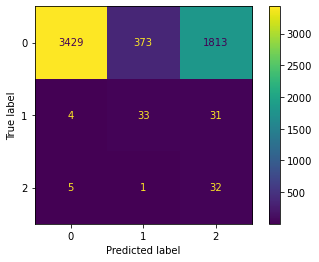

In [12]:
actual = a['DME']
predicted = a['Worse']

confusion_matrix = metrics.confusion_matrix(actual, predicted)

cm_display = metrics.ConfusionMatrixDisplay(confusion_matrix = confusion_matrix)
cm_display.plot()
plt.show()

In [13]:
from sklearn.metrics import classification_report
print(classification_report(actual, predicted))

              precision    recall  f1-score   support

         0.0       1.00      0.61      0.76      5615
         1.0       0.08      0.49      0.14        68
         2.0       0.02      0.84      0.03        38

    accuracy                           0.61      5721
   macro avg       0.37      0.65      0.31      5721
weighted avg       0.98      0.61      0.75      5721



#### Model B

In [14]:
#import B_output
b = pd.read_csv(r"Z:\Data\output-B_upd.csv")
b = b[['SEQN','Laterality', 'DME']]
b = b.pivot(index = 'SEQN', columns = 'Laterality', values = 'DME')
b = pd.merge(df, b, on='SEQN')
print('N in NHANES and Model B: ', b['SEQN'].nunique())

N in NHANES and Model B:  5721


In [15]:
b['Worse'] = b[['OD', 'OS']].max(axis=1)
b = b[['SEQN','DME', 'Worse']]

In [16]:
b.isna().sum()

SEQN     0
DME      0
Worse    0
dtype: int64

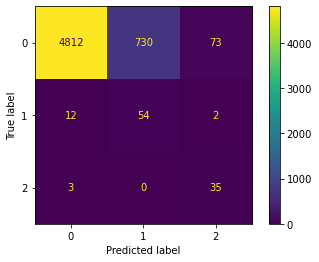

In [17]:
actual = b['DME']
predicted = b['Worse']

confusion_matrix = metrics.confusion_matrix(actual, predicted)

cm_display = metrics.ConfusionMatrixDisplay(confusion_matrix = confusion_matrix)
cm_display.plot()
plt.show()

In [18]:
from sklearn.metrics import classification_report
print(classification_report(actual, predicted))

              precision    recall  f1-score   support

         0.0       1.00      0.86      0.92      5615
         1.0       0.07      0.79      0.13        68
         2.0       0.32      0.92      0.47        38

    accuracy                           0.86      5721
   macro avg       0.46      0.86      0.51      5721
weighted avg       0.98      0.86      0.91      5721



#### Model D

In [19]:
#import D_output
d = pd.read_csv(r"Z:\Data\output-D_upd.csv")
d = d[['SEQN','Laterality', 'DME']]
d = d.pivot(index = 'SEQN', columns = 'Laterality', values = 'DME')
d = pd.merge(df, d, on='SEQN')
print('N in NHANES and Model D: ', d['SEQN'].nunique())

N in NHANES and Model D:  5118


In [20]:
d['Worse'] = d[['OD', 'OS']].max(axis=1)
d = d[['SEQN','DME', 'Worse']]

In [21]:
d.isna().sum()

SEQN     0
DME      0
Worse    0
dtype: int64

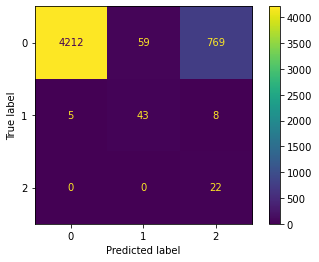

In [22]:
actual = d['DME']
predicted = d['Worse']

confusion_matrix = metrics.confusion_matrix(actual, predicted)

cm_display = metrics.ConfusionMatrixDisplay(confusion_matrix = confusion_matrix)
cm_display.plot()
plt.show()

In [23]:
from sklearn.metrics import classification_report
print(classification_report(actual, predicted))

              precision    recall  f1-score   support

         0.0       1.00      0.84      0.91      5040
         1.0       0.42      0.77      0.54        56
         2.0       0.03      1.00      0.05        22

    accuracy                           0.84      5118
   macro avg       0.48      0.87      0.50      5118
weighted avg       0.99      0.84      0.90      5118



#### Model E

In [24]:
#import E_output
e = pd.read_csv(r"Z:\Data\output-E_upd.csv")
e = e[['SEQN','Laterality', 'DME']]
e = e.pivot(index = 'SEQN', columns = 'Laterality', values = 'DME')
e = pd.merge(df, e, on='SEQN')
print('N in NHANES and Model E: ', e['SEQN'].nunique())

N in NHANES and Model E:  5118


In [25]:
e['Worse'] = e[['OD', 'OS']].max(axis=1)
e = e[['SEQN','DME', 'Worse']]

In [26]:
e.isna().sum()

SEQN     0
DME      0
Worse    0
dtype: int64

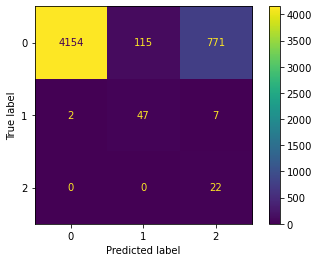

In [27]:
actual = e['DME']
predicted = e['Worse']

confusion_matrix = metrics.confusion_matrix(actual, predicted)

cm_display = metrics.ConfusionMatrixDisplay(confusion_matrix = confusion_matrix)
cm_display.plot()
plt.show()

In [28]:
from sklearn.metrics import classification_report
print(classification_report(actual, predicted))

              precision    recall  f1-score   support

         0.0       1.00      0.82      0.90      5040
         1.0       0.29      0.84      0.43        56
         2.0       0.03      1.00      0.05        22

    accuracy                           0.83      5118
   macro avg       0.44      0.89      0.46      5118
weighted avg       0.99      0.83      0.89      5118



#### Model F

In [29]:
#import F_output
f = pd.read_csv(r"Z:\Data\output-F_upd.csv")
f = f[['SEQN','Laterality', 'DME']]
f = f.pivot(index = 'SEQN', columns = 'Laterality', values = 'DME')
f = pd.merge(df, f, on='SEQN')
print('N in NHANES and Model F: ', f['SEQN'].nunique())

N in NHANES and Model F:  5721


In [30]:
f['Worse'] = f[['OD', 'OS']].max(axis=1)
f = f[['SEQN','DME', 'Worse']]

In [31]:
f.isna().sum()

SEQN     0
DME      0
Worse    2
dtype: int64

In [32]:
f = f.dropna()
f['SEQN'].nunique()

5719

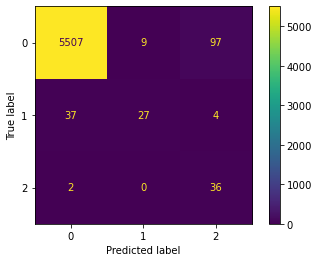

In [33]:
actual = f['DME']
predicted = f['Worse']

confusion_matrix = metrics.confusion_matrix(actual, predicted)

cm_display = metrics.ConfusionMatrixDisplay(confusion_matrix = confusion_matrix)
cm_display.plot()
plt.show()

In [34]:
from sklearn.metrics import classification_report
print(classification_report(actual, predicted))

              precision    recall  f1-score   support

         0.0       0.99      0.98      0.99      5613
         1.0       0.75      0.40      0.52        68
         2.0       0.26      0.95      0.41        38

    accuracy                           0.97      5719
   macro avg       0.67      0.78      0.64      5719
weighted avg       0.99      0.97      0.98      5719



#### Model G

In [35]:
#import G_output
g = pd.read_csv(r"Z:\Data\output - G_upd.csv")
g = g[['SEQN','Laterality', 'DME']]
g = g.pivot(index = 'SEQN', columns = 'Laterality', values = 'DME')
g = pd.merge(df, g, on='SEQN')
print('N in NHANES and Model G: ', g['SEQN'].nunique())

N in NHANES and Model G:  5721


In [36]:
g['Worse'] = g[['OD', 'OS']].max(axis=1)
g = g[['SEQN','DME', 'Worse']]

In [37]:
g.isna().sum()

SEQN     0
DME      0
Worse    0
dtype: int64

In [38]:
g['SEQN'].nunique()

5721

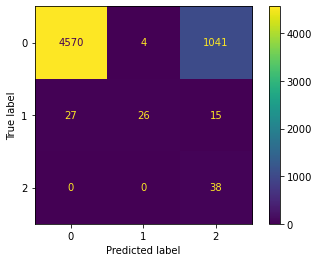

In [39]:
actual = g['DME']
predicted = g['Worse']

confusion_matrix = metrics.confusion_matrix(actual, predicted)

cm_display = metrics.ConfusionMatrixDisplay(confusion_matrix = confusion_matrix)
cm_display.plot()
plt.show()

In [40]:
from sklearn.metrics import classification_report
print(classification_report(actual, predicted))

              precision    recall  f1-score   support

         0.0       0.99      0.81      0.90      5615
         1.0       0.87      0.38      0.53        68
         2.0       0.03      1.00      0.07        38

    accuracy                           0.81      5721
   macro avg       0.63      0.73      0.50      5721
weighted avg       0.99      0.81      0.89      5721



#### Model H

In [41]:
#import H_output
h = pd.read_csv(r"Z:\Data\output-H_upd.csv")
h = h[['SEQN','Laterality', 'DME']]
h = h.pivot(index = 'SEQN', columns = 'Laterality', values = 'DME')
h = pd.merge(df, h, on='SEQN')
print('N in NHANES and Model H: ', h['SEQN'].nunique())

N in NHANES and Model H:  5721


In [42]:
h['Worse'] = h[['OD', 'OS']].max(axis=1)
h = h[['SEQN','DME', 'Worse']]

In [43]:
h.isna().sum()

SEQN     0
DME      0
Worse    0
dtype: int64

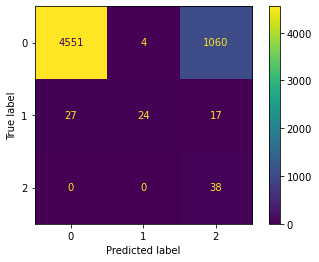

In [44]:
actual = h['DME']
predicted = h['Worse']

confusion_matrix = metrics.confusion_matrix(actual, predicted)

cm_display = metrics.ConfusionMatrixDisplay(confusion_matrix = confusion_matrix)
cm_display.plot()
plt.show()

In [45]:
from sklearn.metrics import classification_report
print(classification_report(actual, predicted))

              precision    recall  f1-score   support

         0.0       0.99      0.81      0.89      5615
         1.0       0.86      0.35      0.50        68
         2.0       0.03      1.00      0.07        38

    accuracy                           0.81      5721
   macro avg       0.63      0.72      0.49      5721
weighted avg       0.99      0.81      0.88      5721



#### ROC
*probs for models a, b, d, f, g, h

In [46]:
from sklearn.metrics import roc_curve
from sklearn.metrics import roc_auc_score
from matplotlib import pyplot

In [48]:
# import probability
prob_a = pd.read_csv(r"Z:\Data\A_prob_upd.csv")
prob_a = prob_a[['SEQN','Laterality', 'DME_prob']]
prob_a = prob_a.pivot(index = 'SEQN', columns = 'Laterality', values = 'DME_prob')
prob_a = pd.merge(df, prob_a, on='SEQN')
print('N: ', prob_a['SEQN'].nunique())

N:  5721


In [50]:
prob_a['Worse'] = prob_a[['OD', 'OS']].max(axis=1)
prob_a = prob_a[['SEQN','DME', 'Worse']]

In [51]:
prob_a.isna().sum()

SEQN        0
DME         0
Worse    1047
dtype: int64

In [52]:
prob_a = prob_a.dropna()
prob_a['SEQN'].nunique()

4674

In [55]:
actual = prob_a['DME']
predicted = prob_a['Worse']
a_fpr, a_tpr, thresholds = metrics.roc_curve(actual, predicted, pos_label=1)

In [64]:
# import probability
prob_b = pd.read_csv(r"Z:\Data\probs-B_upd.csv")
prob_b = prob_b[['SEQN','Laterality', 'DME_prob']]
prob_b = prob_b.pivot(index = 'SEQN', columns = 'Laterality', values = 'DME_prob')
prob_b = pd.merge(df, prob_b, on='SEQN')
print('N: ', prob_b['SEQN'].nunique())

N:  5721


In [65]:
prob_b['Worse'] = prob_b[['OD', 'OS']].max(axis=1)
prob_b = prob_b[['SEQN','DME', 'Worse']]

In [66]:
prob_b.isna().sum()

SEQN      0
DME       0
Worse    27
dtype: int64

In [67]:
prob_b = prob_b.dropna()
prob_b['SEQN'].nunique()

5694

In [68]:
actual = prob_b['DME']
predicted = prob_b['Worse']
b_fpr, b_tpr, thresholds = metrics.roc_curve(actual, predicted, pos_label=1)

In [70]:
# import probability
prob_d = pd.read_csv(r"Z:\Data\prob-d_upd.csv")
prob_d = prob_d[['SEQN','Laterality', 'DME_prob']]
prob_d = prob_d.pivot(index = 'SEQN', columns = 'Laterality', values = 'DME_prob')
prob_d = pd.merge(df, prob_d, on='SEQN')
print('N: ', prob_d['SEQN'].nunique())

N:  5118


In [71]:
prob_d['Worse'] = prob_d[['OD', 'OS']].max(axis=1)
prob_d = prob_d[['SEQN','DME', 'Worse']]

In [72]:
prob_d.isna().sum()

SEQN       0
DME        0
Worse    305
dtype: int64

In [73]:
prob_d = prob_d.dropna()
prob_d['SEQN'].nunique()

4813

In [74]:
actual = prob_d['DME']
predicted = prob_d['Worse']
d_fpr, d_tpr, thresholds = metrics.roc_curve(actual, predicted, pos_label=1)

In [92]:
# import probability
prob_e = pd.read_csv(r"Z:\Data\prob-d_upd.csv")
prob_e = prob_e[['SEQN','Laterality', 'DME_prob']]
prob_e = prob_e.pivot(index = 'SEQN', columns = 'Laterality', values = 'DME_prob')
prob_e = pd.merge(df, prob_e, on='SEQN')
print('N: ', prob_e['SEQN'].nunique())

N:  5118


In [93]:
prob_e['Worse'] = prob_e[['OD', 'OS']].max(axis=1)
prob_e = prob_e[['SEQN','DME', 'Worse']]

In [94]:
prob_e.isna().sum()

SEQN       0
DME        0
Worse    305
dtype: int64

In [95]:
prob_e = prob_e.dropna()
prob_e['SEQN'].nunique()

4813

In [96]:
actual = prob_e['DME']
predicted = prob_e['Worse']
e_fpr, e_tpr, thresholds = metrics.roc_curve(actual, predicted, pos_label=1)

In [76]:
# import probability
prob_f = pd.read_csv(r"Z:\Data\prob-F_upd.csv")
prob_f = prob_f[['SEQN','Laterality', 'DME_prob']]
prob_f = prob_f.pivot(index = 'SEQN', columns = 'Laterality', values = 'DME_prob')
prob_f = pd.merge(df, prob_f, on='SEQN')
print('N: ', prob_f['SEQN'].nunique())

N:  5721


In [77]:
prob_f['Worse'] = prob_f[['OD', 'OS']].max(axis=1)
prob_f = prob_f[['SEQN','DME', 'Worse']]

In [78]:
prob_f.isna().sum()

SEQN      0
DME       0
Worse    40
dtype: int64

In [79]:
prob_f = prob_f.dropna()
prob_f['SEQN'].nunique()

5681

In [80]:
actual = prob_f['DME']
predicted = prob_f['Worse']
f_fpr, f_tpr, thresholds = metrics.roc_curve(actual, predicted, pos_label=1)

In [82]:
# import probability
prob_g = pd.read_csv(r"Z:\Data\prob - G_upd.csv")
prob_g = prob_g[['SEQN','Laterality', 'DME_prob']]
prob_g = prob_g.pivot(index = 'SEQN', columns = 'Laterality', values = 'DME_prob')
prob_g = pd.merge(df, prob_g, on='SEQN')
print('N: ', prob_g['SEQN'].nunique())

N:  5721


In [83]:
prob_g['Worse'] = prob_g[['OD', 'OS']].max(axis=1)
prob_g = prob_g[['SEQN','DME', 'Worse']]

In [84]:
prob_g.isna().sum()

SEQN     0
DME      0
Worse    0
dtype: int64

In [85]:
actual = prob_g['DME']
predicted = prob_g['Worse']
g_fpr, g_tpr, thresholds = metrics.roc_curve(actual, predicted, pos_label=1)

In [87]:
# import probability
prob_h = pd.read_csv(r"Z:\Data\prob-H_upd.csv")
prob_h = prob_h[['SEQN','Laterality', 'DME_prob']]
prob_h = prob_h.pivot(index = 'SEQN', columns = 'Laterality', values = 'DME_prob')
prob_h = pd.merge(df, prob_h, on='SEQN')
print('N: ', prob_h['SEQN'].nunique())

N:  5721


In [88]:
prob_h['Worse'] = prob_h[['OD', 'OS']].max(axis=1)
prob_h = prob_h[['SEQN','DME', 'Worse']]

In [89]:
actual = prob_h['DME']
predicted = prob_h['Worse']
h_fpr, h_tpr, thresholds = metrics.roc_curve(actual, predicted, pos_label=1)

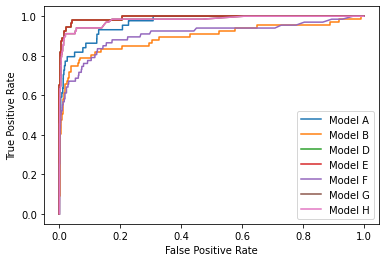

In [97]:
pyplot.plot(a_fpr, a_tpr, label='Model A')
pyplot.plot(b_fpr, b_tpr, label='Model B')
pyplot.plot(d_fpr, d_tpr, label='Model D')
pyplot.plot(e_fpr, e_tpr, label='Model E')
pyplot.plot(f_fpr, f_tpr, label='Model F')
pyplot.plot(g_fpr, g_tpr, label='Model G')
pyplot.plot(h_fpr, h_tpr, label='Model H')
pyplot.xlabel('False Positive Rate')
pyplot.ylabel('True Positive Rate')
pyplot.legend()
pyplot.show()

In [98]:
plt.savefig(r"Z:\Output\Data tables\ROC\DME.svg", format='svg', dpi=1200)

<Figure size 432x288 with 0 Axes>